### Cluster 2 (2620 companies, 75 bankrupt)
### Strategy: Stacking with Class-Weighted Random Forest & HistGradientBoosting

In [17]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
    StackingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, recall_score
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [18]:
# Configuration
CLUSTER_ID = 2
INPUT_FILE = f"cluster_{CLUSTER_ID}.csv"
FEATURE_FILE = "top_features_for_clustering.joblib"
OUTPUT_MODEL = f"cluster{CLUSTER_ID}_stacking.joblib"
RANDOM_STATE = 42

# Data Loading
print(f"Loading data for Cluster {CLUSTER_ID}...")
df = pd.read_csv(INPUT_FILE)
print(f"Shape: {df.shape}")
print(f"Class Distribution:\n{df['Bankrupt?'].value_counts()}")

Loading data for Cluster 2...
Shape: (2620, 98)
Class Distribution:
Bankrupt?
0    2545
1      75
Name: count, dtype: int64


In [19]:
features_to_use = joblib.load(FEATURE_FILE)
print(f"Loaded {len(features_to_use)} selected features.")

X = df[features_to_use]
y = df["Bankrupt?"]

Loaded 40 selected features.


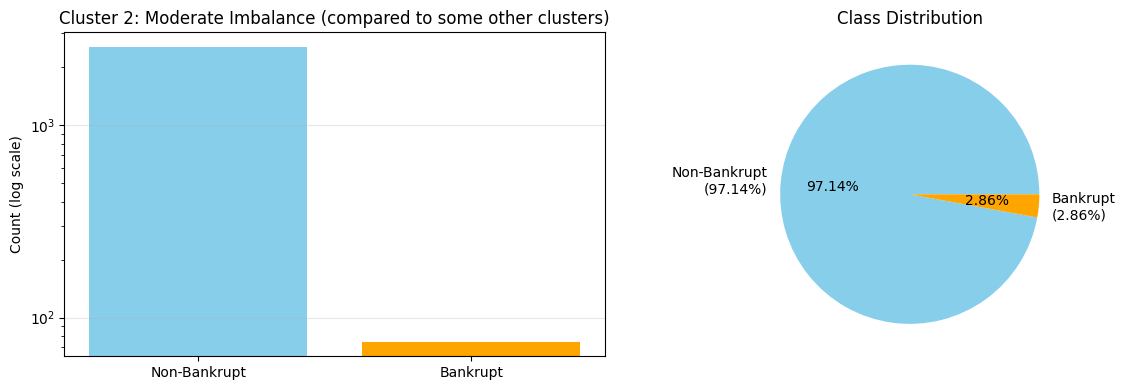

In [20]:
class_counts = y.value_counts().sort_index()
non_bankrupt_count = class_counts[0]
bankrupt_count = class_counts[1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(
    ["Non-Bankrupt", "Bankrupt"],
    [non_bankrupt_count, bankrupt_count],
    color=["skyblue", "orange"],
)
axes[0].set_ylabel("Count (log scale)")
axes[0].set_yscale("log")
axes[0].set_title(
    f"Cluster {CLUSTER_ID}: Moderate Imbalance (compared to some other clusters)"
)
axes[0].grid(axis="y", alpha=0.3)

total = non_bankrupt_count + bankrupt_count
axes[1].pie(
    [non_bankrupt_count, bankrupt_count],
    labels=[
        f"Non-Bankrupt\n({non_bankrupt_count/total*100:.2f}%)",
        f"Bankrupt\n({bankrupt_count/total*100:.2f}%)",
    ],
    colors=["skyblue", "orange"],
    autopct="%1.2f%%",
)
axes[1].set_title("Class Distribution")

plt.tight_layout()
plt.savefig(f"cluster{CLUSTER_ID}_class_distribution.png", dpi=300)
plt.show()

In [21]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

hgb = HistGradientBoostingClassifier(
    learning_rate=0.05, max_iter=200, class_weight="balanced", random_state=RANDOM_STATE
)

lr_base = LogisticRegression(
    class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE
)


estimators = [("rf", rf), ("hgb", hgb), ("lr", lr_base)]

# Stacking Classifier
stacking_layer = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(class_weight="balanced"),
    cv=5,
    n_jobs=-1,
)

clf_stack = make_pipeline(
    StandardScaler(), PCA(n_components=10, random_state=RANDOM_STATE), stacking_layer
)

clf_stack.fit(X, y)
print("Training Complete.")

Training Complete.


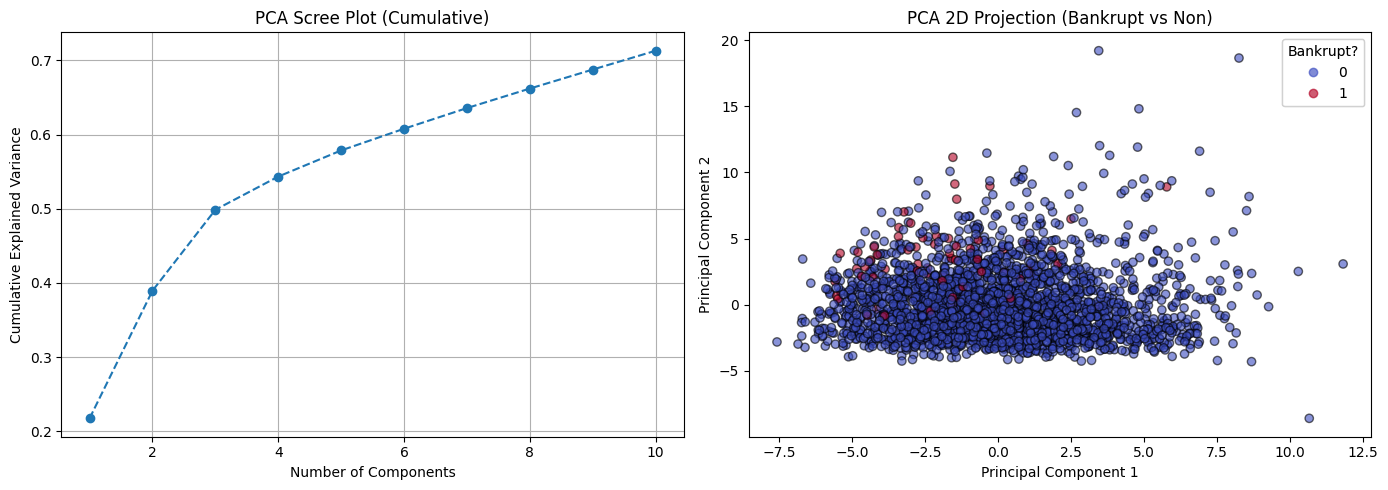

In [22]:
# Visual 3: PCA Analysis
pca_model = clf_stack.named_steps["pca"]
explained_variance = np.cumsum(pca_model.explained_variance_ratio_)
X_pca = clf_stack[:-1].transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree Plot
axes[0].plot(range(1, 11), explained_variance, marker="o", linestyle="--")
axes[0].set_xlabel("Number of Components")
axes[0].set_ylabel("Cumulative Explained Variance")
axes[0].set_title("PCA Scree Plot (Cumulative)")
axes[0].grid(True)

# 2D Scatter Projection (PC1 vs PC2)
# Note: Imbalance is present but moderate compared to Cluster 1
scatter = axes[1].scatter(
    X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", alpha=0.6, edgecolors="k"
)
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")
axes[1].set_title("PCA 2D Projection (Bankrupt vs Non)")
legend1 = axes[1].legend(*scatter.legend_elements(), title="Bankrupt?")
axes[1].add_artist(legend1)

plt.tight_layout()
plt.show()

RESULTS FOR TABLE 3 (Cluster 2)

Base Model Performance (on full train set, post-PCA):
Base: rf
Confusion Matrix: [[2528, 17], [0, 75]]
Eq(1) Accuracy: 1.0000
Base: hgb
Confusion Matrix: [[2545, 0], [0, 75]]
Eq(1) Accuracy: 1.0000
Base: lr
Confusion Matrix: [[1977, 568], [14, 61]]
Eq(1) Accuracy: 0.8133

Stacking Model Performance (Final):
STACKING MODEL
Confusion Matrix: [[2006, 539], [0, 75]]
Eq(1) Accuracy: 1.0000


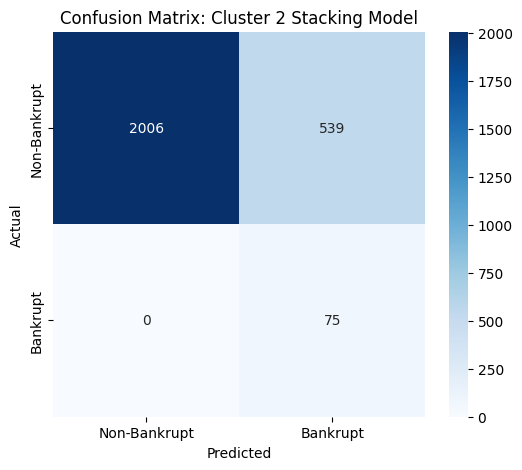

TT: 75, TF: 0, N_features: 10


In [23]:
# Evaluation
def get_metrics(y_true, y_pred, name):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    FF, FT, TF, TT = cm.ravel()

    acc_eq1 = TT / (TF + TT) if (TF + TT) > 0 else 0

    print(f"{name}")
    print(f"Confusion Matrix: [[{FF}, {FT}], [{TF}, {TT}]]")
    print(f"Eq(1) Accuracy: {acc_eq1:.4f}")
    return FF, FT, TF, TT, acc_eq1


print(f"RESULTS FOR TABLE 3 (Cluster {CLUSTER_ID})")

X_transformed = clf_stack[:-1].transform(X)
stacking_model = clf_stack[-1]

# Base Model Performance
print("\nBase Model Performance (on full train set, post-PCA):")
for name, est in stacking_model.named_estimators_.items():
    y_pred_base = est.predict(X_transformed)
    get_metrics(y, y_pred_base, f"Base: {name}")

# Stacking Model Performance
print("\nStacking Model Performance (Final):")
y_pred_stack = clf_stack.predict(X)
FF, FT, TF, TT, acc = get_metrics(y, y_pred_stack, "STACKING MODEL")

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y, y_pred_stack)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Bankrupt", "Bankrupt"],
    yticklabels=["Non-Bankrupt", "Bankrupt"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix: Cluster {CLUSTER_ID} Stacking Model")
plt.show()

model_package = {
    "cluster_id": CLUSTER_ID,
    "features": features_to_use,
    "model": clf_stack,
    "stats": {"TT": TT, "TF": TF, "N_features": 10},
}

joblib.dump(model_package, OUTPUT_MODEL)

print(f"TT: {TT}, TF: {TF}, N_features: 10")

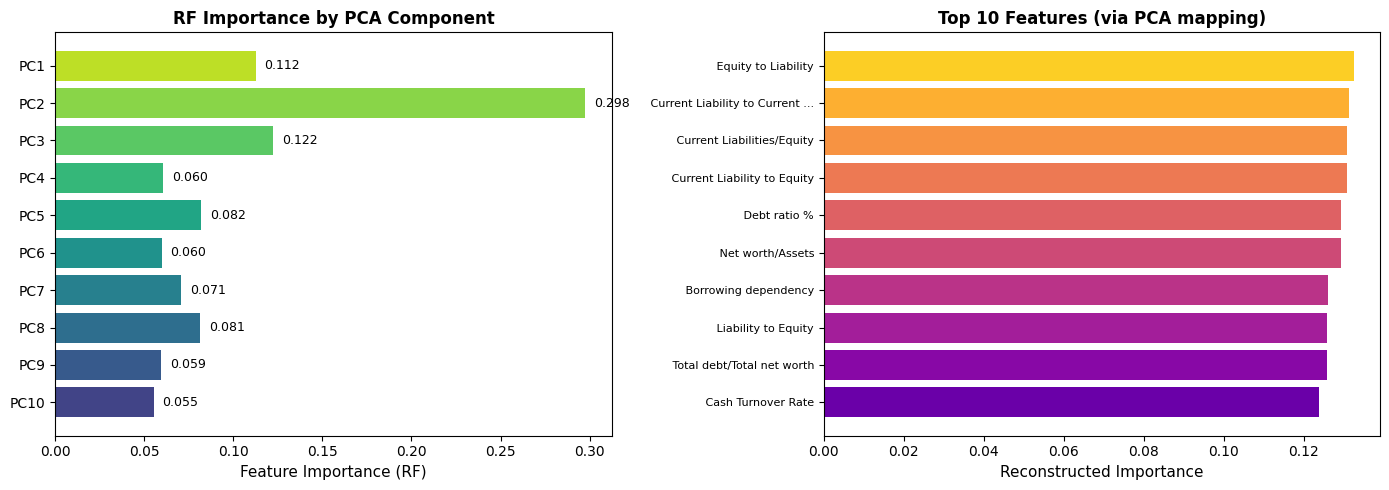

Top 10 Most Important Features:
   1.  Equity to Liability                               : 0.1324
   2.  Current Liability to Current Assets               : 0.1314
   3.  Current Liabilities/Equity                        : 0.1308
   4.  Current Liability to Equity                       : 0.1308
   5.  Debt ratio %                                      : 0.1292
   6.  Net worth/Assets                                  : 0.1292
   7.  Borrowing dependency                              : 0.1259
   8.  Liability to Equity                               : 0.1259
   9.  Total debt/Total net worth                        : 0.1259
  10.  Cash Turnover Rate                                : 0.1238


In [24]:
# Feature Importance Analysis from Random Forest Base Model
# Get the RF model from the stacking layer
rf_model = stacking_model.named_estimators_['rf']

# Get PCA component importances from RF
pca_importances = rf_model.feature_importances_
pca_model = clf_stack.named_steps['pca']

# PCA Component Importances (what RF sees)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
pca_comp_names = [f'PC{i+1}' for i in range(len(pca_importances))]
bars1 = ax1.barh(pca_comp_names[::-1], pca_importances[::-1], color=plt.cm.viridis(np.linspace(0.2, 0.9, len(pca_importances))))
ax1.set_xlabel('Feature Importance (RF)', fontsize=11)
ax1.set_title('RF Importance by PCA Component', fontsize=12, fontweight='bold')
for bar, val in zip(bars1, pca_importances[::-1]):
    ax1.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)

# Map back to original features (approximate contribution)
# Reconstruct original feature importance by weighting PCA components
original_feature_importance = np.abs(pca_model.components_.T) @ pca_importances
feature_importance_df = pd.Series(original_feature_importance, index=features_to_use).sort_values(ascending=False)

top_features = feature_importance_df.head(10)
ax2 = axes[1]
short_names = [name[:30] + '...' if len(name) > 30 else name for name in top_features.index[::-1]]
bars2 = ax2.barh(range(len(top_features)), top_features.values[::-1], 
                 color=plt.cm.plasma(np.linspace(0.2, 0.9, len(top_features))))
ax2.set_yticks(range(len(top_features)))
ax2.set_yticklabels(short_names, fontsize=8)
ax2.set_xlabel('Reconstructed Importance', fontsize=11)
ax2.set_title('Top 10 Features (via PCA mapping)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f"cluster{CLUSTER_ID}_feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

print("Top 10 Most Important Features:")
for i, (feat, imp) in enumerate(feature_importance_df.head(10).items(), 1):
    print(f"  {i:2d}. {feat[:50]:50s} : {imp:.4f}")